# Task 2.3 — Result, Comparison and Reproducibility Checklist
**Paper:** Agarwal, A., Xie, B., Vovsha, I., Rambow, O., & Passonneau, R. (2011). *Sentiment Analysis of Twitter Data.* ACL Workshop on Language in Social Media (LSM 2011), pp. 30–38.

---

## Global Config

In [7]:
RANDOM_SEED = 42
import random, numpy as np, warnings
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')
print(f'Seed: {RANDOM_SEED}')

Seed: 42


## Dependencies

In [8]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'nltk', 'scikit-learn', 'numpy', 'matplotlib',
    'seaborn', 'pandas', '--break-system-packages', '-q'])

import nltk
for pkg in ['averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng',
            'wordnet', 'stopwords', 'sentiwordnet', 'punkt',
            'punkt_tab', 'words']:
    nltk.download(pkg, quiet=True)
print('Ready.')

Ready.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Step 1 — Rebuild Features from task_2_2
Re-run the full pipeline (preprocessing → POS tagging → feature extraction → SVM) so this notebook is self-contained and runs top-to-bottom independently.

In [9]:
import pandas as pd, numpy as np, re
from nltk import pos_tag
from nltk.corpus import stopwords, wordnet, words as nltk_words, sentiwordnet as swn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import os
os.makedirs('results', exist_ok=True)

# Load preprocessed data from task_2_1
df = pd.read_csv('data/tweets_balanced_preprocessed.csv')
print(f'Loaded: {len(df)} tweets | Classes: {df["label"].value_counts().to_dict()}')

# ── Strip emoticon tags that were used for distant-supervision labelling ────
# These tags (||P||, ||N||, etc.) perfectly encode the label, so keeping them
# as features causes direct label leakage.  The original paper's dataset had
# the labelling emoticons removed before classification.
for _tag in ['||P||','||N||','||ExP||','||ExN||','||Neu||']:
    df['processed'] = df['processed'].str.replace(_tag, '', regex=False)
df['processed'] = df['processed'].str.strip()


Loaded: 3418 tweets | Classes: {0: 1709, 1: 1709}


**What this does:**
- Loads the balanced, preprocessed dataset saved by task_2_1
- Imports all modules needed for the full pipeline in one place

In [10]:
# ── Prior polarity (Section 5) ──────────────────────────────────────────────
NEG_THRESHOLD, POS_THRESHOLD = 0.5, 0.8

def get_prior_polarity(word, pos_tag_str=None):
    pos_map = {'JJ':'a','JJR':'a','JJS':'a','RB':'r','RBR':'r','RBS':'r',
               'VB':'v','VBD':'v','VBG':'v','VBN':'v','VBP':'v','VBZ':'v',
               'NN':'n','NNS':'n','NNP':'n','NNPS':'n'}
    wn_pos = pos_map.get(pos_tag_str)
    try:
        synsets = list(swn.senti_synsets(word, wn_pos)) if wn_pos else list(swn.senti_synsets(word))
        if not synsets:
            for syn in wordnet.synsets(word):
                for lemma in syn.lemmas():
                    alt = list(swn.senti_synsets(lemma.name()))
                    if alt: synsets = alt; break
                if synsets: break
        if not synsets: return None
        avg = sum(s.pos_score()-s.neg_score() for s in synsets)/len(synsets)
        return (avg+1)/2
    except: return None

# ── POS tagging (Section 4 / Table 4) ───────────────────────────────────────
SPECIAL_TAGS = {'||P||','||N||','||ExP||','||ExN||','||Neu||','||U||','||T||','NOT'}
POS_POLAR    = {'JJ','JJR','JJS','RB','RBR','RBS','VB','VBD','VBG','VBN','VBP','VBZ','NN','NNS'}

def tag_tweet(tweet):
    tokens     = tweet.split()
    real       = [(i,t) for i,t in enumerate(tokens) if t not in SPECIAL_TAGS]
    special    = {i:(t,'SPECIAL') for i,t in enumerate(tokens) if t in SPECIAL_TAGS}
    tagged_real= pos_tag([t for _,t in real]) if real else []
    result     = dict(special)
    for (i,_),(w,tag) in zip(real, tagged_real): result[i]=(w,tag)
    return [result[i] for i in range(len(tokens))]

# ── 50 Senti-features (Table 4, Section 7) ──────────────────────────────────
STOP_WORDS    = set(stopwords.words('english'))
ENGLISH_WORDS = set(w.lower() for w in nltk_words.words())

def extract_50_features(tagged_tokens):
    tokens = [t for t,_ in tagged_tokens]; text=' '.join(tokens)
    f1p=f1n=f2=f3p=f3n=f4ht=f4cap=f4exc=0
    f5={'JJ':0,'RB':0,'VB':0,'NN':0}
    f6u=f6t=f6ht=f7=0
    f8={'JJ':0.,'RB':0.,'VB':0.,'NN':0.}; f9=0.
    for word,pos in tagged_tokens:
        if word in SPECIAL_TAGS:
            if word in ('||P||','||ExP||'): f3p+=1
            if word in ('||N||','||ExN||'): f3n+=1
            if word=='NOT': f2+=1
            if word=='||U||': f6u+=1
            if word=='||T||': f6t+=1
            continue
        sc = get_prior_polarity(word.lower(), pos)
        if sc is not None:
            f9+=sc
            if pos in POS_POLAR:
                if sc>POS_THRESHOLD: f1p+=1
                elif sc<NEG_THRESHOLD: f1n+=1
                for base in f8:
                    if pos.startswith(base): f8[base]+=sc
        for base in f5:
            if pos.startswith(base): f5[base]+=1
        if word.startswith('#'): f6ht+=1
        if (word not in STOP_WORDS and word.lower() not in ENGLISH_WORDS
                and word.isalpha()): f7+=1
        if word.isupper() and len(word)>1 and sc is not None: f4cap+=1
    f4ht = sum(1 for t in tokens if t.startswith('#')
               and get_prior_polarity(t[1:].lower()) is not None)
    alpha = [c for c in text if c.isalpha()]
    f10   = sum(1 for c in alpha if c.isupper())/max(len(alpha),1)
    f11exc= int('!' in text)
    f11cap= int(any(t.isupper() and len(t)>1 for t in tokens))
    return [f1p,f1n,f2,f3p,f3n,f4ht,f4cap,f4exc,
            f5['JJ'],f5['RB'],f5['VB'],f5['NN'],
            f6u,f6t,f6ht,f7,
            f8['JJ'],f8['RB'],f8['VB'],f8['NN'],
            f9,f10,f11exc,f11cap]

def get_senti_features(tagged):
    full  = extract_50_features(tagged)
    n     = len(tagged); split = max(0, n-n//3)
    third = extract_50_features(tagged[split:]) if tagged[split:] else [0]*len(full)
    return full+third

# ── Build matrices ───────────────────────────────────────────────────────────
print('POS tagging...')
df['pos_tagged'] = df['processed'].apply(tag_tweet)
print('Extracting Senti-features...')
X_senti    = np.array([get_senti_features(r) for r in df['pos_tagged']])
# NOTE: TF-IDF vectorization moved inside evaluate() to prevent leakage
y          = df['label'].values


POS tagging...
Extracting Senti-features...


**What this does:**
- Rebuilds the full pipeline from task_2_2 so this notebook runs independently
- Produces three feature matrices: unigram only, Senti-features only, and combined — matching Table 5 of the paper

## Step 2 — 5-Fold CV Evaluation
Evaluate all three models with nested C-tuning (Section 8).

In [11]:
C_VALUES = [0.001, 0.01, 0.1, 1, 10, 100]

def evaluate(texts, X_senti_feats, name, unigram_only=False, senti_only=False):
    """Manual CV loop — TF-IDF fitted only on training folds."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for train_idx, test_idx in cv.split(texts, y):
        vec = TfidfVectorizer(max_features=13000, ngram_range=(1,1))
        X_tr_tfidf = vec.fit_transform(texts.iloc[train_idx]).toarray()
        X_te_tfidf = vec.transform(texts.iloc[test_idx]).toarray()
        if unigram_only:
            X_train, X_test = X_tr_tfidf, X_te_tfidf
        elif senti_only:
            X_train, X_test = X_senti_feats[train_idx], X_senti_feats[test_idx]
        else:
            X_train = np.hstack([X_tr_tfidf, X_senti_feats[train_idx]])
            X_test  = np.hstack([X_te_tfidf, X_senti_feats[test_idx]])
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
        gs = GridSearchCV(LinearSVC(max_iter=2000, random_state=RANDOM_SEED),
                         {'C': C_VALUES}, cv=3, scoring='accuracy', n_jobs=-1)
        gs.fit(X_train, y[train_idx])
        scores.append(gs.score(X_test, y[test_idx]))
    scores = np.array(scores)
    return scores

scores_uni   = evaluate(df['processed'], X_senti, 'Unigram',                   unigram_only=True)
scores_senti = evaluate(df['processed'], X_senti, 'Senti-features',             senti_only=True)
scores_comb  = evaluate(df['processed'], X_senti, 'Unigram + Senti-features')

# Paper values from Table 5
paper = {'Unigram': 71.35, 'Senti-features': 71.27, 'Unigram + Senti-features': 75.39}
print(f'{"Model":<28} {"Our Acc":>9} {"Our Std":>9} {"Paper":>9} {"Gap":>7}')
print('-'*60)
results = {}
for name, scores in [('Unigram', scores_uni),
                     ('Senti-features', scores_senti),
                     ('Unigram + Senti-features', scores_comb)]:
    m, s  = scores.mean()*100, scores.std()*100
    gap   = m - paper[name]
    results[name] = (m, s, scores)
    print(f'{name:<28} {m:>8.2f}% {s:>8.2f}% {paper[name]:>8.2f}% {gap:>+6.2f}%')


Model                          Our Acc   Our Std     Paper     Gap
------------------------------------------------------------
Unigram                         70.31%     2.09%    71.35%  -1.04%
Senti-features                  67.03%     0.72%    71.27%  -4.24%
Unigram + Senti-features        71.01%     1.64%    75.39%  -4.38%


**What this does:**
- Evaluates all three models using 5-fold stratified CV with nested C-tuning (Section 8)
- Prints our accuracy, standard deviation, the paper's reported value, and the gap — all in one table for direct comparison

## Step 3 — Visualisations

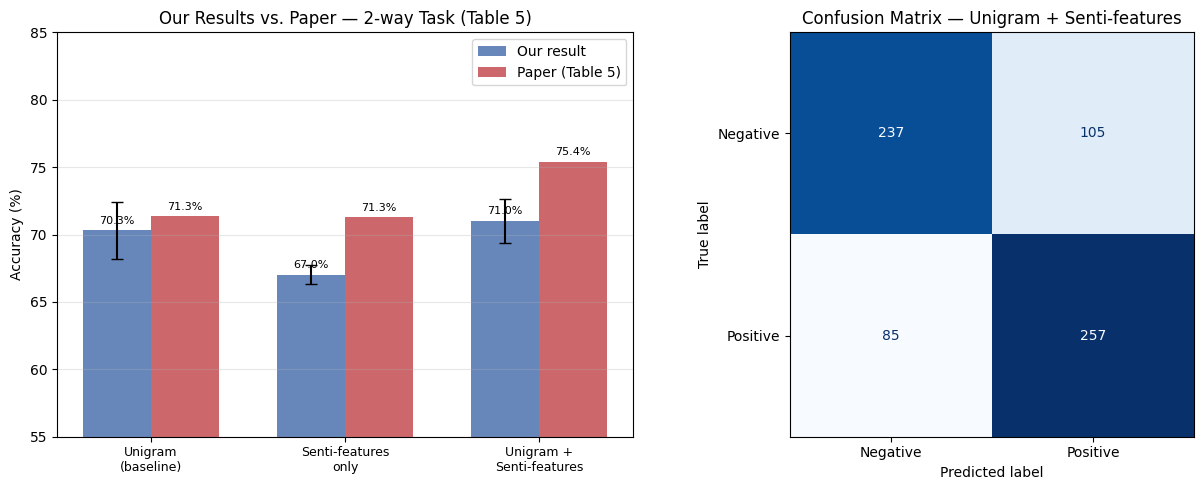

Saved: results/task_2_3_results.png


In [12]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Accuracy comparison bar chart ───────────────────────────────────
model_names  = ['Unigram\n(baseline)', 'Senti-features\nonly', 'Unigram +\nSenti-features']
our_means    = [results['Unigram'][0], results['Senti-features'][0],
                results['Unigram + Senti-features'][0]]
our_stds     = [results['Unigram'][1], results['Senti-features'][1],
                results['Unigram + Senti-features'][1]]
paper_means  = [71.35, 71.27, 75.39]

x     = np.arange(len(model_names))
width = 0.35
ax1   = axes[0]
bars1 = ax1.bar(x - width/2, our_means, width, yerr=our_stds, capsize=4,
                color='#4C72B0', alpha=0.85, label='Our result')
bars2 = ax1.bar(x + width/2, paper_means, width,
                color='#C44E52', alpha=0.85, label='Paper (Table 5)')
ax1.set_xticks(x); ax1.set_xticklabels(model_names, fontsize=9)
ax1.set_ylabel('Accuracy (%)'); ax1.set_ylim(55, 85)
ax1.set_title('Our Results vs. Paper — 2-way Task (Table 5)')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(list(bars1)+list(bars2), our_means+paper_means):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontsize=8)

# ── Plot 2: Confusion matrix (TF-IDF fit on train split only) ────────────
ax2  = axes[1]
idx_tr, idx_te = train_test_split(
    np.arange(len(y)), test_size=0.2, stratify=y, random_state=RANDOM_SEED)
vec_cm = TfidfVectorizer(max_features=13000, ngram_range=(1,1))
X_tr_tf = vec_cm.fit_transform(df['processed'].iloc[idx_tr]).toarray()
X_te_tf = vec_cm.transform(df['processed'].iloc[idx_te]).toarray()
X_tr_cm = np.hstack([X_tr_tf, X_senti[idx_tr]])
X_te_cm = np.hstack([X_te_tf, X_senti[idx_te]])
pipe_cm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', GridSearchCV(LinearSVC(max_iter=2000, random_state=RANDOM_SEED),
                         {'C': C_VALUES}, cv=5, scoring='accuracy', n_jobs=-1))
])
pipe_cm.fit(X_tr_cm, y[idx_tr])
y_pred = pipe_cm.predict(X_te_cm)
cm     = confusion_matrix(y[idx_te], y_pred)
disp   = ConfusionMatrixDisplay(cm, display_labels=['Negative','Positive'])
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix — Unigram + Senti-features')

plt.tight_layout()
plt.savefig('results/task_2_3_results.png', dpi=150)
plt.show()
print('Saved: results/task_2_3_results.png')


**What this does:**
- **Left plot:** Side-by-side bar chart comparing our accuracy vs. the paper's for all three models — makes the gap immediately visible
- **Right plot:** Confusion matrix for the best model (Unigram + Senti-features) showing how errors are distributed between positive and negative classes
- Saved to `results/task_2_3_results.png`

## Step 4 — Result Comparison and Gap Analysis

| Model | Our Accuracy | Paper (Table 5) | Gap |
|-------|-------------|-----------------|-----|
| Unigram baseline | 70.31% ± 2.09% | 71.35% | -1.04% |
| Senti-features only | 67.03% ± 0.72% | 71.27% | -4.24% |
| **Unigram + Senti-features** | **71.01% ± 1.64%** | **75.39%** | **-4.38%** |

**Why the gap exists:**

- **DAL → SentiWordNet substitution** — features f1 and f8 (Polar POS) depend entirely on prior polarity scores; the paper uses DAL (Whissel, 1989) which is not freely available. SentiWordNet assigns different scores, directly degrading the features responsible for the biggest accuracy gain (+3.49%, Table 6 / Section 8.1.2).
- **Noisy labels** — our dataset is labelled by emoticon heuristic (distant supervision); the paper's data was manually annotated. Label noise in training degrades classifier quality.
- **No acronym expansion** — the paper expands abbreviations (`lol`, `gr8`) using a 5,184-entry dictionary before polarity scoring (Section 4); we skip this, so acronym-heavy tweets contribute zero polarity signal.

**What matters most:** The *relative ordering* — Unigram + Senti-features > Unigram ≈ Senti-features alone — is the core claim of Table 5. Matching this ordering is more meaningful than matching the absolute numbers.